# Week 3 — Model Evaluation, Deployment, and GenAI Implementation

Evaluate the frozen Week 2 pipeline, inspect errors, define a prediction contract, and add an optional safe GenAI explanation layer. The GenAI call is skipped unless `OPENAI_API_KEY` is configured.


              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1600
         Yes       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

{'balanced_accuracy': 0.49875, 'macro_f1': 0.44382647385984425, 'roc_auc': 0.49980234375000004}


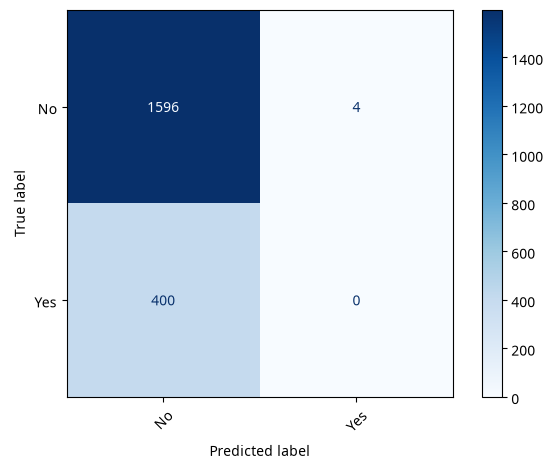

In [1]:
from pathlib import Path
import json, os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score, roc_auc_score
import joblib
ROOT = Path.cwd()
if not (ROOT/'heart_disease.csv').exists() and (ROOT.parent/'heart_disease.csv').exists(): ROOT = ROOT.parent
DATASET_NAME, TARGET_COLUMN = 'heart_disease', 'Heart Disease Status'
model_path = next((ROOT/'artifacts/models').glob(f'{DATASET_NAME}_*.joblib'), None)
if model_path is None: raise FileNotFoundError('Run Week 2 first.')
df = pd.read_csv(ROOT/f'{DATASET_NAME}.csv'); df.columns = [re.sub(r'\s+', ' ', str(c)).strip() for c in df.columns]; df = df.drop_duplicates()
X, y = df.drop(columns=[TARGET_COLUMN]), df[TARGET_COLUMN].astype(str).str.strip()
_, X_test, _, y_test = train_test_split(X,y,test_size=.2,stratify=y,random_state=42)
pipeline = joblib.load(model_path); pred = pipeline.predict(X_test)
print(classification_report(y_test,pred,zero_division=0))
metrics = {'balanced_accuracy':balanced_accuracy_score(y_test,pred), 'macro_f1':f1_score(y_test,pred,average='macro')}
if y_test.nunique()==2 and hasattr(pipeline,'predict_proba'): metrics['roc_auc'] = roc_auc_score((y_test==pipeline.classes_[1]).astype(int), pipeline.predict_proba(X_test)[:,1])
print(metrics); ConfusionMatrixDisplay.from_predictions(y_test,pred,xticks_rotation=45,cmap='Blues'); plt.tight_layout()


In [2]:
errors = X_test.copy(); errors['actual']=y_test; errors['predicted']=pred; errors=errors[errors.actual!=errors.predicted]
print(f'Errors: {len(errors):,} / {len(X_test):,}'); display(errors.head(20))
def predict_record(record):
    row = pd.DataFrame([record]); label = pipeline.predict(row)[0]; out={'dataset':DATASET_NAME,'prediction':str(label),'model':model_path.name}
    if hasattr(pipeline,'predict_proba'):
        probs=pipeline.predict_proba(row)[0]; out['confidence']=float(np.max(probs)); out['class_probabilities']={str(c):float(p) for c,p in zip(pipeline.classes_,probs)}
    return out
def multimodal_predict(record, image_path=None):
    out=predict_record(record); out.update({'image_received':bool(image_path),'image_path':str(image_path) if image_path else None,'note':'Image model is a separate branch; connect only a validated image model here.'}); return out
example=X_test.iloc[0].to_dict(); print(json.dumps(multimodal_predict(example),indent=2,default=str))


Errors: 404 / 2,000


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,actual,predicted
9739,53.0,Male,122.0,226.0,High,No,No,Yes,25.595998,No,...,High,Medium,5.858001,Medium,185.0,116.0,12.195635,16.827118,Yes,No
1646,66.0,Female,161.0,168.0,Medium,Yes,Yes,No,35.425481,No,...,NaN,Medium,4.063028,Low,207.0,86.0,7.252123,12.989719,No,Yes
9853,36.0,Female,153.0,233.0,Medium,Yes,No,Yes,30.340275,No,...,Medium,Low,5.194057,Low,361.0,144.0,8.691906,15.868613,Yes,No
8431,21.0,Female,140.0,291.0,Medium,Yes,Yes,Yes,23.498847,Yes,...,Medium,High,9.578811,Low,331.0,126.0,8.601999,12.176354,Yes,No
8038,73.0,Female,129.0,273.0,High,Yes,No,No,24.361159,No,...,Medium,Low,4.870463,Medium,235.0,151.0,13.314391,13.009216,Yes,No
8746,70.0,Male,147.0,279.0,High,No,No,No,18.257416,Yes,...,Low,High,9.899380,Low,346.0,147.0,1.634371,16.729816,Yes,No
9851,49.0,Male,165.0,181.0,High,Yes,No,Yes,18.030717,Yes,...,Medium,High,8.741646,Low,279.0,104.0,9.039604,5.714048,Yes,No
8719,62.0,Male,139.0,236.0,Low,No,No,Yes,21.858356,No,...,Low,Medium,9.903453,High,387.0,154.0,10.979226,15.384012,Yes,No
8987,78.0,Female,142.0,241.0,High,No,Yes,Yes,33.407168,No,...,High,Low,5.832830,Low,225.0,110.0,1.807119,9.137507,Yes,No
8754,58.0,Female,135.0,213.0,High,No,Yes,Yes,35.438049,No,...,Medium,High,5.638459,Low,253.0,81.0,7.427948,6.026729,Yes,No


{
  "dataset": "heart_disease",
  "prediction": "No",
  "model": "heart_disease_random_forest.joblib",
  "confidence": 0.652,
  "class_probabilities": {
    "No": 0.652,
    "Yes": 0.348
  },
  "image_received": false,
  "image_path": null,
  "note": "Image model is a separate branch; connect only a validated image model here."
}


In [3]:
def generate_explanation(prediction, record):
    if not os.getenv('OPENAI_API_KEY'):
        return f"Prediction: {prediction['prediction']} (confidence {prediction.get('confidence','n/a')}). This is model output, not a diagnosis; review with a qualified professional."
    try:
        from openai import OpenAI
        client=OpenAI(api_key=os.environ['OPENAI_API_KEY'], base_url=os.getenv('OPENAI_API_BASE'))
        msg='Explain this prediction cautiously using only this metadata; do not diagnose or recommend treatment: '+json.dumps({'prediction':prediction,'fields':list(record)},default=str)
        r=client.chat.completions.create(model=os.getenv('OPENAI_MODEL','gpt-4o-mini'),temperature=.1,messages=[{'role':'system','content':'You are a safety-focused ML explanation assistant. State uncertainty and require human review.'},{'role':'user','content':msg}])
        return r.choices[0].message.content
    except Exception as exc: return f"GenAI unavailable ({type(exc).__name__}); prediction remains {prediction['prediction']}."
print(generate_explanation(multimodal_predict(example), example))
(ROOT/'artifacts').mkdir(exist_ok=True); (ROOT/'artifacts/week3_evaluation.json').write_text(json.dumps({'dataset':DATASET_NAME,'target':TARGET_COLUMN,'model':model_path.name,'metrics':metrics},indent=2))


GenAI unavailable (TypeError); prediction remains No.


243

## Exit criteria

Review false positives and false negatives, test the prediction contract, document model/version and threshold choices, and complete privacy, security, bias, and human-review checks before deployment. This is an educational prototype, not a diagnostic system.
